In [99]:
import numpy as np
import jax
import jax.numpy as jnp
import jaxdem as jd

jax.config.update("jax_enable_x64", True)

state = jd.utils.h5.load('jammed_state.h5')
old_system = jd.utils.h5.load('jammed_system.h5')

delta_phi = -1e-2
phi = jnp.sum(state.volume) / jnp.prod(old_system.domain.box_size)
scale = phi / (phi + delta_phi)
old_system.domain.box_size *= scale
state.pos_c *= scale

mats = [jd.Material.create("elastic", young=1.0, poisson=0.5, density=1.0)]
matcher = jd.MaterialMatchmaker.create("harmonic")
mat_table = jd.MaterialTable.from_materials(mats, matcher=matcher)

system = jd.System.create(
    state_shape=state.shape,
    dt=1e-2,
    linear_integrator_type="verlet",
    rotation_integrator_type="verletspiral",
    domain_type="periodic",
    force_model_type="spring",
    collider_type="naive",
    # collider_type="celllist",
    # collider_kw=dict(state=state),
    mat_table=mat_table,
    domain_kw=dict(
        box_size=old_system.domain.box_size,
    ),
)


seed = np.random.randint(0, 1000000)
key = jax.random.PRNGKey(seed)
key_vel, key_angVel = jax.random.split(key, 2)
cid, offsets = jnp.unique(state.ID, return_index=True)
N_clumps = cid.size
clump_vel = jax.random.normal(key_vel, (N_clumps, state.dim))
clump_vel -= jnp.mean(clump_vel, axis=0)
state.vel = clump_vel[state.ID]
ke_t = jnp.sum(0.5 * state.mass * jnp.sum(state.vel ** 2, axis=-1))
# ke_r ?????
dof = (state.dim + state.inertia.shape[-1]) * N_clumps - state.dim
current_temp = 2 * ke_t / dof
scale = jnp.sqrt(1e-4 / current_temp)
state.vel *= scale

n_steps = 1_000
save_stride = 1
n_snapshots = n_steps // save_stride
final_state, final_system, (traj_state, traj_system) = jd.System.trajectory_rollout(
    state, system, n=n_snapshots, stride=save_stride
)

In [100]:
import matplotlib.pyplot as plt
_, offsets = jnp.unique(state.ID, return_index=True)

pe = jnp.sum(
    jax.vmap(lambda st, sys: 
    sys.collider.compute_potential_energy(st, sys))(traj_state, traj_system),
    axis=-1
)
ke_t = 0.5 * jnp.sum(traj_state.mass[:, offsets] * jnp.sum(traj_state.vel[:, offsets, :] ** 2, axis=-1), axis=-1)
w = traj_state.q.rotate_back(traj_state.q, traj_state.angVel)
ke_r = jnp.sum((0.5 * jnp.vecdot(w, traj_state.inertia * w))[:, offsets], axis=-1)
ke = ke_t + ke_r

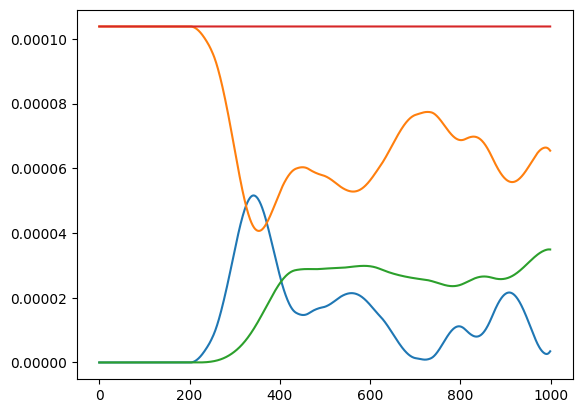

In [103]:
plt.plot(pe)
plt.plot(ke_t)
plt.plot(ke_r)
plt.plot(pe + ke_t + ke_r)

In [ ]:
_, offsets = jnp.unique(state.ID, return_index=True)

pe = jnp.sum(
    jax.vmap(
        lambda st, sys:
        sys.collider.compute_potential_energy(st, sys))(traj_state, traj_system)[:, offsets],
    axis=-1
)
ke_t = jnp.sum((0.5 * traj_state.mass * jnp.vecdot(traj_state.vel, traj_state.vel))[:, offsets], axis=-1)
w = traj_state.q.rotate_back(traj_state.q, traj_state.angVel)
ke_r = jnp.sum((0.5 * jnp.vecdot(w, traj_state.inertia * w))[:, offsets], axis=-1)
ke = ke_t + ke_r

import matplotlib.pyplot as plt
plt.plot(pe, label='pe')
plt.plot(ke_t, label='ke_t')
plt.plot(ke_r, label='ke_r')
plt.plot(ke_r + ke_t + pe, label='te')
plt.legend()
plt.savefig('energies.png')
plt.close()

import subprocess
from pathlib import Path
import h5py
with h5py.File("traj.h5", "w") as f:
    f.create_dataset("pos", data=np.asarray(traj_state.pos))
    f.create_dataset("rad", data=np.asarray(traj_state.rad))
    f.create_dataset("ID", data=np.asarray(traj_state.ID))
    f.create_dataset("box_size", data=np.asarray(traj_system.domain.box_size))